In [3]:
import sys
print(sys.executable)

/Users/leandrabraeuninger/Library/CloudStorage/OneDrive-UniversityCollegeLondon/20_continuos ancestry PRS/.venv/bin/python


# Simulating a Simple Ancestry Cohort with tskit/msprime

This notebook implements the 8-stage pipeline for generating training/test
genotype-phenotype cohorts with a **continuous genetic ancestry gradient**,
for testing the kernel-based ancestry-aware PRS. Each stage has a sanity-check
plot immediately after it.

**Pipeline stages:**
~~1. Demographic model (stepping-stone chain)~~
1. simulate a simple population
2. Simulate the ancestral recombination graph (ARG)
~~3. Overlay mutations~~
4. Extract genotype matrix
~~5. QC and standardize~~
6. Derive ancestry coordinates (PCA)
7. Simulate phenotypes
8. Train/test cohort split by ancestry

In [4]:
import numpy as np
import msprime
import tskit
import tstrait
import tskit_arg_visualizer as argviz
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)

## Stage 1 — Simulate simple coalescense



In [7]:
# ts = msprime.sim_ancestry(samples=5, ploidy=2, population_size=1_000, sequence_length=1e4, recombination_rate=1e-8)  # NB ploidy=2 is the default, so can be omitted
# we'll move up to 10'000 individuals next, first proof of concept with 1000, later we'll make a bigger population


# Define a demography with 3 populations
demography = msprime.Demography()
demography.add_population(name="pop_A", initial_size=100)
demography.add_population(name="pop_B", initial_size=100)
demography.add_population(name="pop_C", initial_size=100)

# Simulate ancestry: ~1000 individuals total, split across the 3 populations
ts = msprime.sim_ancestry(
    samples={"pop_A": 4, "pop_B": 3, "pop_C": 3},
    demography=demography,
    sequence_length=1000,       # length of the simulated genome region (bp)
    recombination_rate=1e-8,    # per-base recombination rate
    random_seed=42,
)

print(ts)

KeyboardInterrupt: 

In [ ]:
# if we want to simulate mutations
mts = msprime.sim_mutations(ts, rate=1e-8, random_seed=42)

In [ ]:
# let's try if the inbuilt PCA works already
plot_pca_by_pop(ts)

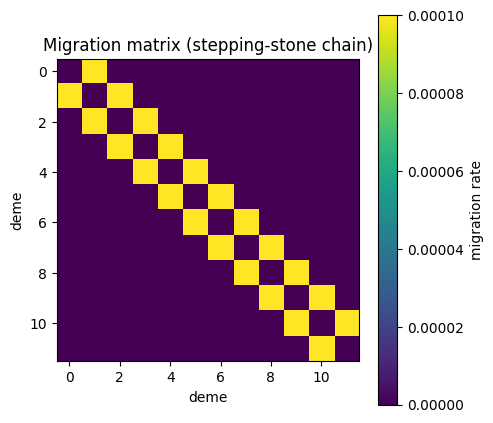

Demography
╟  Populations
║  ┌─────────────────────────────────────────────────────────────────────────────────────────────────┐
║  │ id │name    │description  │initial_size  │ growth_rate │  default_sampling_time│extra_metadata  │
║  ├─────────────────────────────────────────────────────────────────────────────────────────────────┤
║  │ 0  │pop_0   │             │1000.0        │      0      │                      0│{}              │
║  │ 1  │pop_1   │             │1000.0        │      0      │                      0│{}              │
║  │ 2  │pop_2   │             │1000.0        │      0      │                      0│{}              │
║  │ 3  │pop_3   │             │1000.0        │      0      │                      0│{}              │
║  │ 4  │pop_4   │             │1000.0        │      0      │                      0│{}              │
║  │ 5  │pop_5   │             │1000.0        │      0      │                      0│{}              │
║  │ 6  │pop_6   │             │1000.0        │

In [34]:
demography = msprime.Demography.stepping_stone_model(
    initial_size=[NE] * N_DEMES,
    migration_rate=MIGRATION_RATE,
    boundaries=True,
)

M = demography.migration_matrix
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(M, cmap="viridis")
ax.set_title("Migration matrix (stepping-stone chain)")
ax.set_xlabel("deme"); ax.set_ylabel("deme")
plt.colorbar(im, label="migration rate")
plt.tight_layout()
plt.show()

print(demography)

## Stage 2 — Simulate the ancestral recombination graph (ARG)

`msprime.sim_ancestry` runs the coalescent under the demographic model above,
producing a tree sequence: the exact genealogy of every sampled haplotype at
every position along the chromosome.

**Sanity check:** the number of distinct local trees should be large (many
recombination breakpoints) and increase roughly with sequence length /
recombination rate; genealogies should differ across demes, which we can spot
by looking at the pairwise coalescence-time (TMRCA) structure below.

Number of local trees: 18099
Number of individuals: 480
Number of sample nodes (haplotypes): 960


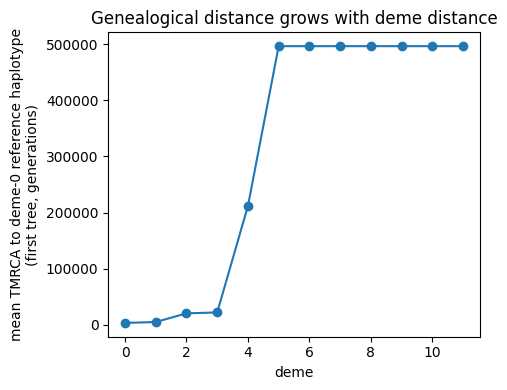

In [4]:
samples = {f"pop_{i}": N_PER_DEME for i in range(N_DEMES)}

ts_ancestry = msprime.sim_ancestry(
    samples=samples,
    demography=demography,
    sequence_length=SEQ_LENGTH,
    recombination_rate=RECOMB_RATE,
    ploidy=2,
    random_seed=int(rng.integers(1, 2**31)),
)

print(f"Number of local trees: {ts_ancestry.num_trees}")
print(f"Number of individuals: {ts_ancestry.num_individuals}")
print(f"Number of sample nodes (haplotypes): {ts_ancestry.num_samples}")

# sanity check: mean pairwise TMRCA should increase with deme distance
deme_of_node = np.repeat(np.arange(N_DEMES), N_PER_DEME * 2)  # haploid-level deme label
tree = ts_ancestry.first()
# sample a few individuals per deme and compute TMRCA to deme 0's first haplotype
ref_node = 0
mean_tmrca = []
for d in range(N_DEMES):
    nodes_d = np.where(deme_of_node == d)[0]
    tmrcas = [tree.tmrca(ref_node, int(n)) for n in nodes_d[:10]]
    mean_tmrca.append(np.mean(tmrcas))

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(range(N_DEMES), mean_tmrca, marker="o")
ax.set_xlabel("deme")
ax.set_ylabel("mean TMRCA to deme-0 reference haplotype\n(first tree, generations)")
ax.set_title("Genealogical distance grows with deme distance")
plt.tight_layout()
plt.show()

## Stage 3 — Overlay mutations

`msprime.sim_mutations` places neutral mutations on the ARG branches. Because
mutations sit on a known genealogy, the resulting genotypes automatically
carry realistic LD and allele-frequency structure — no separate LD simulation
needed.

**Sanity check:** the site-frequency spectrum (SFS) should have the classic
decreasing shape (most variants rare, few common), and multiallelic sites
(which we drop, since our standardization assumes biallelic SNPs) should be
a small minority.

Number of sites (pre-filter): 48711
Fraction multiallelic (dropped): 0.005
Number of biallelic sites (kept): 48478


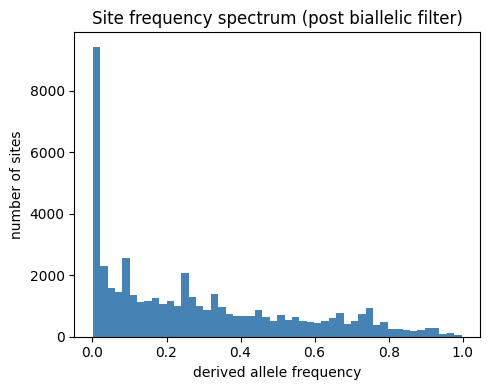

In [5]:
ts = msprime.sim_mutations(ts_ancestry, rate=MUT_RATE, random_seed=int(rng.integers(1, 2**31)))
print(f"Number of sites (pre-filter): {ts.num_sites}")

n_alleles = np.array([len(s.mutations) for s in ts.sites()])
frac_multiallelic = (n_alleles != 1).mean()
print(f"Fraction multiallelic (dropped): {frac_multiallelic:.3f}")

multiallelic_ids = [s.id for s in ts.sites() if len(s.mutations) != 1]
if multiallelic_ids:
    ts = ts.delete_sites(multiallelic_ids)
print(f"Number of biallelic sites (kept): {ts.num_sites}")

Ghap_preview = ts.genotype_matrix()
allele_counts = Ghap_preview.sum(axis=1)
freqs = allele_counts / Ghap_preview.shape[1]

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(freqs, bins=50, color="steelblue")
ax.set_xlabel("derived allele frequency")
ax.set_ylabel("number of sites")
ax.set_title("Site frequency spectrum (post biallelic filter)")
plt.tight_layout()
plt.show()

## Stage 4 — Extract the genotype matrix

Fold haploid 0/1 calls into diploid allele counts $G_{is}\in\{0,1,2\}$ per
individual per site — structurally identical to real array/WGS genotype data.

**Sanity check:** a heatmap of genotypes, with individuals sorted by deme,
should show visible block structure (individuals from the same/nearby demes
share more alleles) rather than looking uniformly random.

Genotype matrix G: 480 individuals x 48478 sites


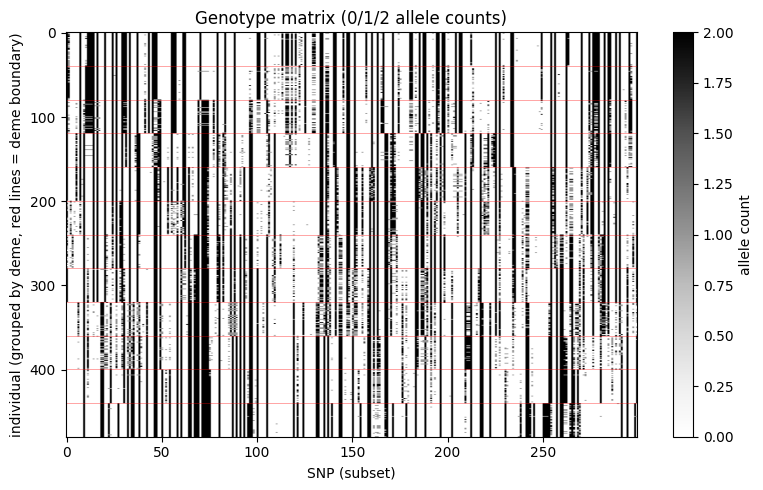

In [6]:
Ghap = ts.genotype_matrix()                 # (sites, haploid_samples)
G = Ghap[:, 0::2] + Ghap[:, 1::2]           # fold to diploid, (sites, n_ind)
G = G.T                                      # (n_ind, sites) -> G_is convention

deme = np.repeat(np.arange(N_DEMES), N_PER_DEME)
print(f"Genotype matrix G: {G.shape[0]} individuals x {G.shape[1]} sites")

# subsample sites for a readable heatmap
site_subset = rng.choice(G.shape[1], size=min(300, G.shape[1]), replace=False)
site_subset.sort()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(G[:, site_subset], aspect="auto", cmap="Greys", vmin=0, vmax=2)
for d in range(1, N_DEMES):
    ax.axhline(d * N_PER_DEME - 0.5, color="red", linewidth=0.5, alpha=0.5)
ax.set_xlabel("SNP (subset)")
ax.set_ylabel("individual (grouped by deme, red lines = deme boundary)")
ax.set_title("Genotype matrix (0/1/2 allele counts)")
plt.colorbar(im, label="allele count")
plt.tight_layout()
plt.show()

## Stage 5 — QC and standardize

Filter rare variants (MAF < `MAF_MIN`), then standardize genotypes:
$x_{is} = (G_{is} - 2f_s)/\sqrt{2f_s(1-f_s)}$ (slide 3 convention).

**Sanity check:** allele frequency histogram before vs after MAF filtering
(the filtered version should have the low-frequency tail removed), and
confirm standardized genotypes have ~zero mean, ~unit variance per SNP.

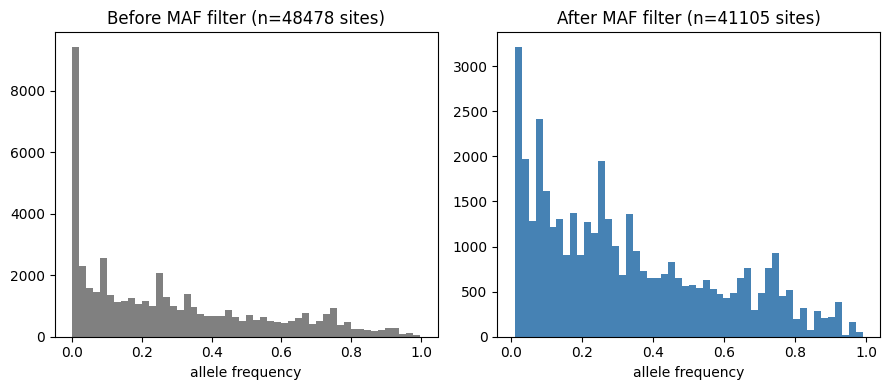

Standardized X: (480, 41105)
Per-SNP mean of X (should be ~0): 0.0000
Per-SNP var of X (should be ~1): 1.7274


In [7]:
f_s_all = G.mean(axis=0) / 2
keep = (f_s_all > MAF_MIN) & (f_s_all < 1 - MAF_MIN)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].hist(f_s_all, bins=50, color="grey")
axes[0].set_title(f"Before MAF filter (n={G.shape[1]} sites)")
axes[0].set_xlabel("allele frequency")
axes[1].hist(f_s_all[keep], bins=50, color="steelblue")
axes[1].set_title(f"After MAF filter (n={keep.sum()} sites)")
axes[1].set_xlabel("allele frequency")
plt.tight_layout()
plt.show()

G_qc = G[:, keep]
f_s = f_s_all[keep]
X = (G_qc - 2 * f_s) / np.sqrt(2 * f_s * (1 - f_s))

print(f"Standardized X: {X.shape}")
print(f"Per-SNP mean of X (should be ~0): {X.mean():.4f}")
print(f"Per-SNP var of X (should be ~1): {X.var(axis=0).mean():.4f}")

## Stage 6 — Derive ancestry coordinates (PCA)

Run PCA on the standardized genotypes to get PC projections $z_i$.

**Sanity check:** since the demography is a 1D continuum, PC1 should track
deme position closely (near-monotone), and a PC1 vs PC2 scatter colored by
deme should show a smooth gradient/arc rather than discrete clusters —
this is the key validation that the simulation produces a genuine continuum.

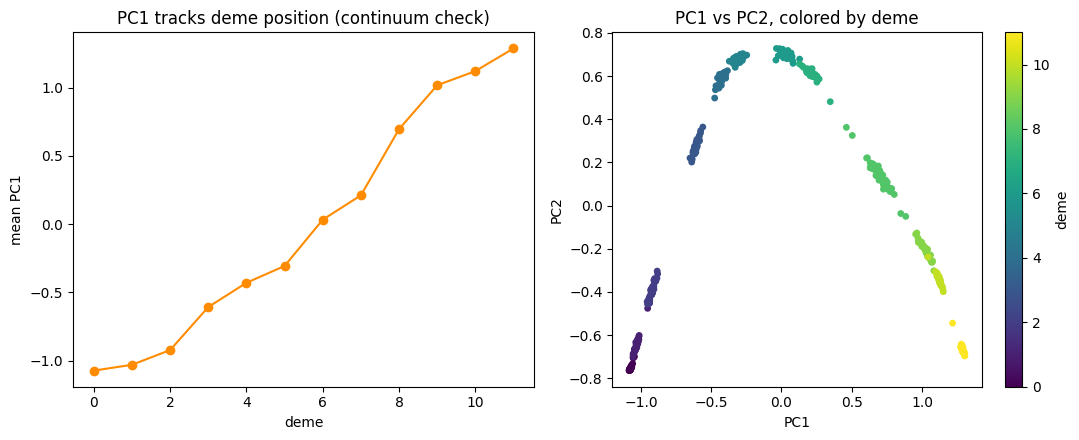

explained variance ratio (first 5 PCs): [0.396 0.169 0.081 0.058 0.039]


In [8]:
pca = PCA(n_components=N_PC, random_state=42)
Z = pca.fit_transform(X / np.sqrt(X.shape[1]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# PC1 mean by deme -- should be monotone
pc1_by_deme = [Z[deme == d, 0].mean() for d in range(N_DEMES)]
axes[0].plot(range(N_DEMES), pc1_by_deme, marker="o", color="darkorange")
axes[0].set_xlabel("deme")
axes[0].set_ylabel("mean PC1")
axes[0].set_title("PC1 tracks deme position (continuum check)")

sc = axes[1].scatter(Z[:, 0], Z[:, 1], c=deme, cmap="viridis", s=15)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("PC1 vs PC2, colored by deme")
plt.colorbar(sc, ax=axes[1], label="deme")
plt.tight_layout()
plt.show()

print("explained variance ratio (first 5 PCs):", pca.explained_variance_ratio_[:5].round(3))

## Stage 7 — Simulate phenotypes (via `tstrait`)

[`tstrait`](https://github.com/tskit-dev/tstrait) simulates quantitative
phenotypes directly on a tree sequence: it picks causal sites, draws effect
sizes from a chosen distribution, computes each individual's genetic value
from their actual genotypes at those sites, and adds environmental noise to
hit a target heritability.

We then add an **optional ancestry-dependent drift term** on top of
`tstrait`'s baseline genetic value: each causal SNP's effective effect size
drifts linearly with the individual's own PC1 position (`ANCESTRY_EFFECT_HETEROGENEITY`).
This deliberately breaks the fixed-$\beta$ assumption behind the linear
kernel — ground truth for testing whether the RBF kernel recovers
ancestry-varying effects. #TODO: check whether this makes sense

**Sanity check:** causal effect-size histogram (from `tstrait`'s trait
dataframe), phenotype distribution, and genetic value vs. PC1 (heterogeneity
should show up as a trend/spread).

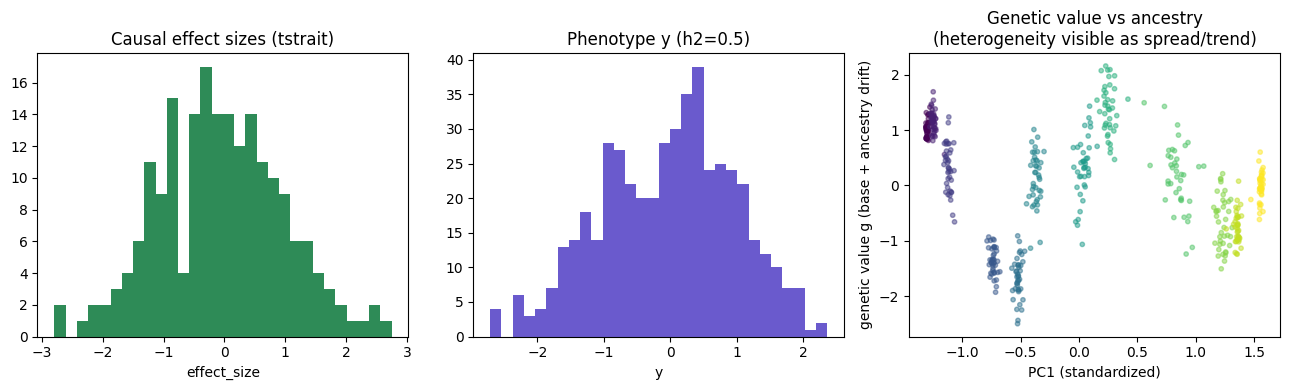

var(g_drift) / var(g_total): 0.065  (0 if heterogeneity=0)


In [9]:
# import tstrait

z1 = (Z[:, 0] - Z[:, 0].mean()) / Z[:, 0].std()

model = tstrait.trait_model(distribution="normal", mean=0, var=1)
result = tstrait.sim_phenotype(
    ts, model=model, num_causal=N_CAUSAL, h2=HERITABILITY,
    random_seed=int(rng.integers(1, 2**31)),
)

trait_df = result.trait          # site_id, effect_size, allele_freq, ...
pheno_df = result.phenotype      # individual_id, genetic_value, environmental_noise, phenotype

# pheno_df.individual_id follows ts.individuals() order, which is grouped by
# deme in the order demes were sampled -> aligns directly with `deme` array.
assert (pheno_df["individual_id"].values == np.arange(ts.num_individuals)).all()

g_base = pheno_df["genetic_value"].values

if ANCESTRY_EFFECT_HETEROGENEITY > 0:
    # extract genotypes at tstrait's own causal sites (from the full ts, not
    # the MAF-filtered kernel SNP set, to keep indices unambiguous)
    causal_site_ids = trait_df["site_id"].values
    causal_effects = trait_df["effect_size"].values
    Ghap_causal = ts.genotype_matrix()[causal_site_ids, :]
    G_causal = Ghap_causal[:, 0::2] + Ghap_causal[:, 1::2]     # (n_causal, n_ind)
    G_causal = G_causal.T                                       # (n_ind, n_causal)
    f_causal = G_causal.mean(axis=0) / 2
    Xc = (G_causal - 2 * f_causal) / np.sqrt(2 * f_causal * (1 - f_causal) + 1e-9)

    drift = ANCESTRY_EFFECT_HETEROGENEITY * np.outer(z1, causal_effects)
    g_drift = (Xc * drift).sum(axis=1) / np.sqrt(len(causal_effects))
    g_total = g_base + g_drift
else:
    g_drift = np.zeros_like(g_base)
    g_total = g_base

g_total = (g_total - g_total.mean()) / g_total.std()
y = np.sqrt(HERITABILITY) * g_total + np.sqrt(1 - HERITABILITY) * rng.normal(0, 1, size=len(g_total))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(trait_df["effect_size"], bins=30, color="seagreen")
axes[0].set_title("Causal effect sizes (tstrait)")
axes[0].set_xlabel("effect_size")

axes[1].hist(y, bins=30, color="slateblue")
axes[1].set_title(f"Phenotype y (h2={HERITABILITY})")
axes[1].set_xlabel("y")

axes[2].scatter(z1, g_total, s=10, alpha=0.5, c=deme, cmap="viridis")
axes[2].set_xlabel("PC1 (standardized)")
axes[2].set_ylabel("genetic value g (base + ancestry drift)")
axes[2].set_title("Genetic value vs ancestry\n(heterogeneity visible as spread/trend)")
plt.tight_layout()
plt.show()

print(f"var(g_drift) / var(g_total): {np.var(g_drift)/np.var(g_total):.3f}  (0 if heterogeneity=0)")

## Stage 8 — Train/test split by ancestry

Training cohort restricted to `TRAIN_DEMES` (mimicking a Eurocentric
biobank); test cohort spans all remaining demes.

**Sanity check:** genetic distance from each test individual to the training
centroid (in PC space) should increase monotonically with deme distance from
the training demes — this is the x-axis you'll use for the portability-decay
evaluation in WP3.

Training cohort: n=120 (demes [0, 1, 2])
Test cohort:     n=360 (demes [3, 4, 5, 6, 7, 8, 9, 10, 11])


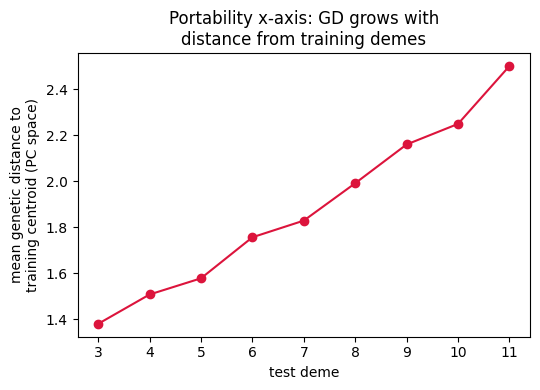

In [10]:
train_mask = np.isin(deme, TRAIN_DEMES)
test_mask = ~train_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
Z_train, Z_test = Z[train_mask], Z[test_mask]
deme_train, deme_test = deme[train_mask], deme[test_mask]

print(f"Training cohort: n={X_train.shape[0]} (demes {TRAIN_DEMES})")
print(f"Test cohort:     n={X_test.shape[0]} (demes {sorted(set(deme_test.tolist()))})")

centroid = Z_train.mean(axis=0)
gd_test = np.linalg.norm(Z_test - centroid, axis=1)

gd_by_deme = [gd_test[deme_test == d].mean() for d in sorted(set(deme_test.tolist()))]

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(sorted(set(deme_test.tolist())), gd_by_deme, marker="o", color="crimson")
ax.set_xlabel("test deme")
ax.set_ylabel("mean genetic distance to\ntraining centroid (PC space)")
ax.set_title("Portability x-axis: GD grows with\ndistance from training demes")
plt.tight_layout()
plt.show()

=== Genotype matrix summary ===
G (raw allele counts): 480 individuals x 48478 sites, dtype=int32
X (standardized, post-QC): 480 individuals x 41105 sites
Value range in G: [0, 2]  (should be 0/1/2 only)
Genotype value counts: {0: 16197547, 1: 1181096, 2: 5890797}
Missing values in G: 0 (should be 0 -- msprime sims have no missingness)

=== Per-SNP allele frequency (post-QC) ===
f_s range: [0.0104, 0.9896]
f_s mean: 0.3268

=== Per-individual heterozygosity (fraction of het genotypes), by deme ===
Overall mean het rate: 0.0587
  deme  0: mean het rate = 0.0181
  deme  1: mean het rate = 0.0403
  deme  2: mean het rate = 0.0557
  deme  3: mean het rate = 0.0570
  deme  4: mean het rate = 0.0673
  deme  5: mean het rate = 0.0715
  deme  6: mean het rate = 0.0808
  deme  7: mean het rate = 0.0735
  deme  8: mean het rate = 0.1026
  deme  9: mean het rate = 0.0713
  deme 10: mean het rate = 0.0431
  deme 11: mean het rate = 0.0233

=== Standardization check on X ===
Per-SNP mean of X (shou

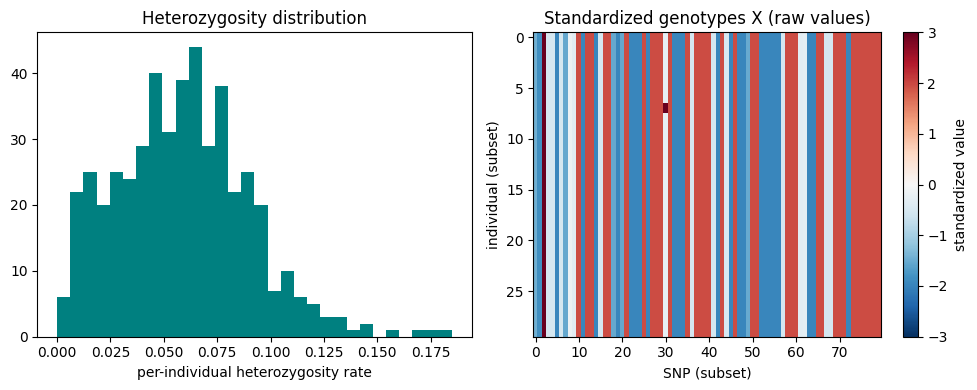

In [11]:
print("=== Genotype matrix summary ===")
print(f"G (raw allele counts): {G.shape[0]} individuals x {G.shape[1]} sites, dtype={G.dtype}")
print(f"X (standardized, post-QC): {X.shape[0]} individuals x {X.shape[1]} sites")
print(f"Value range in G: [{G.min()}, {G.max()}]  (should be 0/1/2 only)")
unique, counts = np.unique(G, return_counts=True)
print(f"Genotype value counts: {dict(zip(unique.tolist(), counts.tolist()))}")
print(f"Missing values in G: {np.isnan(G).sum()} (should be 0 -- msprime sims have no missingness)")

print("\n=== Per-SNP allele frequency (post-QC) ===")
print(f"f_s range: [{f_s.min():.4f}, {f_s.max():.4f}]")
print(f"f_s mean: {f_s.mean():.4f}")

print("\n=== Per-individual heterozygosity (fraction of het genotypes), by deme ===")
het_rate = (G_qc == 1).mean(axis=1)
print(f"Overall mean het rate: {het_rate.mean():.4f}")
for d in range(N_DEMES):
    print(f"  deme {d:2d}: mean het rate = {het_rate[deme == d].mean():.4f}")

print("\n=== Standardization check on X ===")
print(f"Per-SNP mean of X (should be ~0): {X.mean(axis=0).mean():.4f} +/- {X.mean(axis=0).std():.4f}")
print(f"Per-SNP var of X (expected ~1 under HWE): {X.var(axis=0).mean():.4f} +/- {X.var(axis=0).std():.4f}")
print("  (variance > 1 here reflects population structure -- the Wahlund")
print("   effect inflates genotype variance above the single-population")
print("   HWE expectation 2*f*(1-f) used for standardization)")

print("\n=== Raw peek: first 5 individuals x first 10 SNPs ===")
print("Raw G (post-QC):\n", G_qc[:5, :10])
print("Standardized X:\n", np.round(X[:5, :10], 2))

print("\n=== Train/test split sizes ===")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(het_rate, bins=30, color="teal")
axes[0].set_xlabel("per-individual heterozygosity rate")
axes[0].set_title("Heterozygosity distribution")

im = axes[1].imshow(X[:30, :80], aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
axes[1].set_xlabel("SNP (subset)")
axes[1].set_ylabel("individual (subset)")
axes[1].set_title("Standardized genotypes X (raw values)")
plt.colorbar(im, ax=axes[1], label="standardized value")
plt.tight_layout()
plt.show()

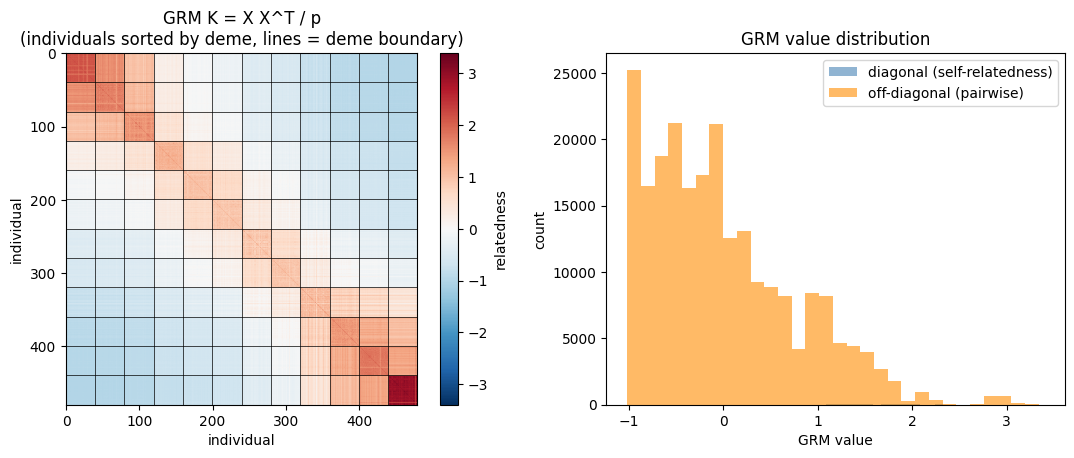

Mean diagonal: 1.7274 (should be ~1 if standardized correctly)
Mean off-diagonal: -0.0036 (should be ~0 for unrelated/unstructured; >0 here due to population structure)


In [12]:
# GRM: K_ij = x_i^T x_j / p  (slide 3 convention)
order = np.argsort(deme)          # sort individuals by deme for visible block structure
X_sorted = X[order]
deme_sorted = deme[order]

p = X.shape[1]
K = (X_sorted @ X_sorted.T) / p

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

vmax = np.abs(K).max()
im = axes[0].imshow(K, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
boundaries = np.cumsum([np.sum(deme_sorted == d) for d in range(N_DEMES)])[:-1]
for b in boundaries:
    axes[0].axhline(b - 0.5, color="black", linewidth=0.5)
    axes[0].axvline(b - 0.5, color="black", linewidth=0.5)
axes[0].set_title("GRM K = X X^T / p\n(individuals sorted by deme, lines = deme boundary)")
axes[0].set_xlabel("individual")
axes[0].set_ylabel("individual")
plt.colorbar(im, ax=axes[0], label="relatedness")

off_diag = K[~np.eye(K.shape[0], dtype=bool)]
axes[1].hist(K.diagonal(), bins=30, alpha=0.6, label="diagonal (self-relatedness)", color="steelblue")
axes[1].hist(off_diag, bins=30, alpha=0.6, label="off-diagonal (pairwise)", color="darkorange")
axes[1].set_xlabel("GRM value")
axes[1].set_ylabel("count")
axes[1].set_title("GRM value distribution")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Mean diagonal: {K.diagonal().mean():.4f} (should be ~1 if standardized correctly)")
print(f"Mean off-diagonal: {off_diag.mean():.4f} (should be ~0 for unrelated/unstructured; >0 here due to population structure)")

There are  18099 trees in this sequence. We are printing only 2 of them.
There are  960 sample nodes in this sequence, which is why the plot is so busy.


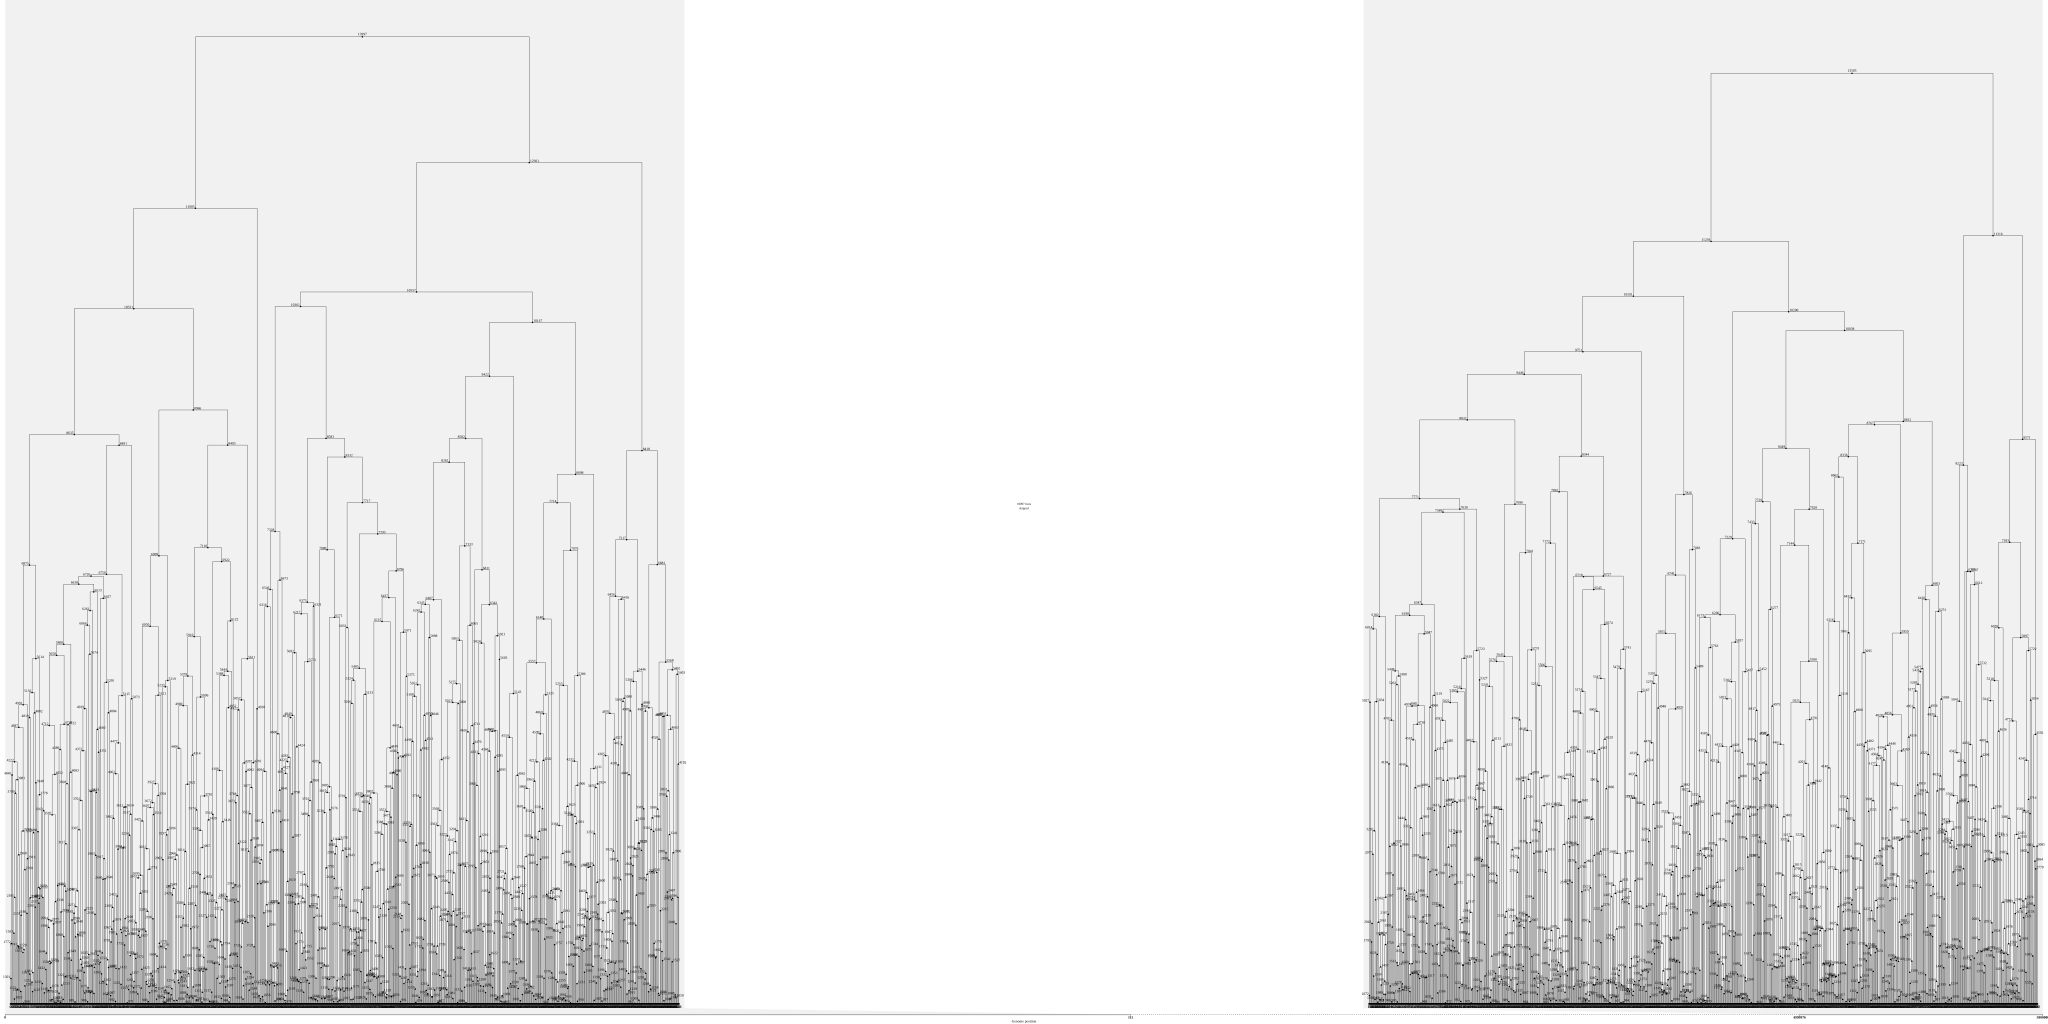

In [30]:
n_trees = ts_ancestry.num_trees
print("There are ", n_trees, "trees in this sequence. We are printing only 2 of them.")
print("There are ", ts_ancestry.num_samples, "sample nodes in this sequence, which is why the plot is so busy.")
ts_ancestry.draw_svg(
    size=(8000, 4000), 
    max_num_trees=2,
    time_scale = "rank"
    )

## Save outputs

#TODO: decide which output format is needed here


In [ ]:
# np.savez_compressed(
#     "/mnt/user-data/outputs/continuum_cohort.npz",
#     X_train=X_train, X_test=X_test,
#     y_train=y_train, y_test=y_test,
#     Z_train=Z_train, Z_test=Z_test,
#     deme_train=deme_train, deme_test=deme_test,
#     beta_causal=beta, causal_idx=causal,
#     f_s=f_s,
# )
# print("Saved -> /mnt/user-data/outputs/continuum_cohort.npz")

Saved -> /mnt/user-data/outputs/continuum_cohort.npz
